In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

/home/benjamin/anaconda3/lib/python3.11/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
"""
Start by loading the gribble deltas
"""

'\nStart by loading the gribble deltas\n'

In [3]:
#Choose to use the gribble summary data, or the filtered data from the manual analysis

USE_GRIBBLE_SUMMARY = False
if USE_GRIBBLE_SUMMARY:
    data = pd.read_excel("./FG combined data Feb 2025.xlsx",sheet_name="all CA deltas",nrows=222,usecols="A:M")
    data = data.drop('Unnamed: 7', axis=1)
else:
    data = pd.read_csv('unscaled_delta.csv')

In [4]:
data

,WT,K186N,L290P,L566R,L776S,N855S,S443C,E179K,H1018R,K390N,Q204K
0,0.10425,0.0020,0.02260,0.01070,0.06545,0.30245,0.018900,0.003786,0.007471,-2.220446e-16,0.005176
1,0.17520,-0.0003,0.05290,0.01035,0.00195,0.32980,0.058500,0.012929,0.090588,3.117647e-03,0.024824
2,0.15925,0.0373,0.02535,0.00860,-0.00045,0.24450,0.032450,0.012357,0.090059,2.411765e-03,0.021765
3,0.13035,0.0550,0.02405,0.12535,0.00370,0.35490,0.062600,0.000357,0.005588,5.529412e-03,0.042294
4,0.16510,0.0021,0.04005,0.11825,0.00490,0.21450,0.009150,0.009071,0.007706,2.176471e-03,0.023529
...,...,...,...,...,...,...,...,...,...,...,...
171,NaN,NaN,NaN,NaN,NaN,NaN,0.000294,NaN,NaN,NaN,NaN
172,NaN,NaN,NaN,NaN,NaN,NaN,0.001235,NaN,NaN,NaN,NaN
173,NaN,NaN,NaN,NaN,NaN,NaN,0.042294,NaN,NaN,NaN,NaN
174,NaN,NaN,NaN,NaN,NaN,NaN,0.000824,NaN,NaN,NaN,NaN


In [5]:
"""
Plot deltas as heatmap
"""

'\nPlot deltas as heatmap\n'

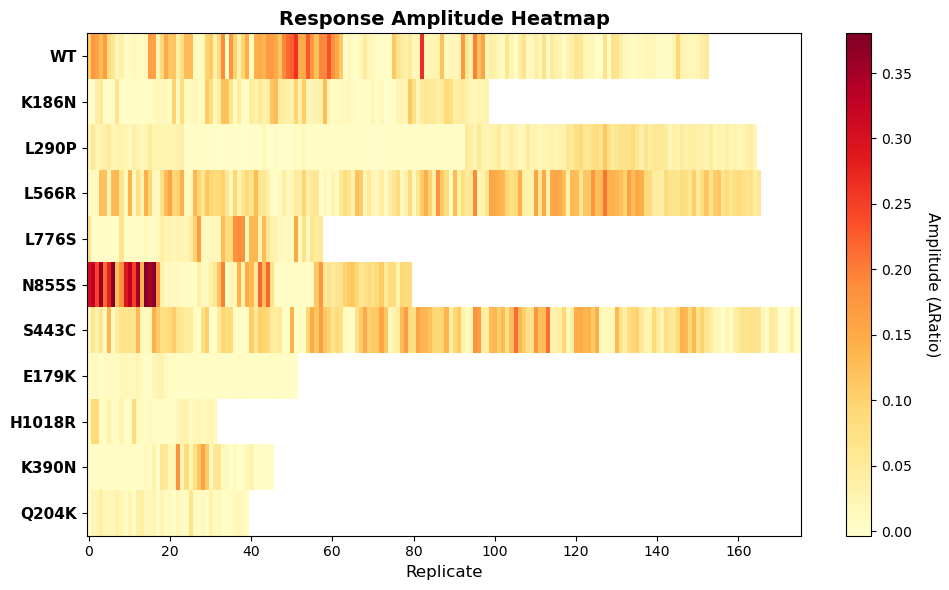

In [6]:
fig3, ax3 = plt.subplots(figsize=(10, 6))

groups = list(data.columns)
max_n = data.count().max()
data_matrix = np.full((len(groups), max_n), np.nan)

for i, group in enumerate(groups):
    values = data[group]
    data_matrix[i, :len(values)] = values

im = ax3.imshow(data_matrix, aspect='auto', cmap='YlOrRd',
                interpolation='nearest')

ax3.set_yticks(np.arange(len(groups)))
ax3.set_yticklabels(groups, fontsize=11, fontweight='bold')
ax3.set_xlabel('Replicate', fontsize=12)
ax3.set_title('Response Amplitude Heatmap', fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax3)
cbar.set_label('Amplitude (ΔRatio)', rotation=270, labelpad=20, fontsize=11)

plt.tight_layout()

In [7]:
data.count()

WT        153
K186N      99
L290P     165
L566R     166
L776S      58
N855S      80
S443C     176
E179K      52
H1018R     32
K390N      46
Q204K      40
dtype: int64

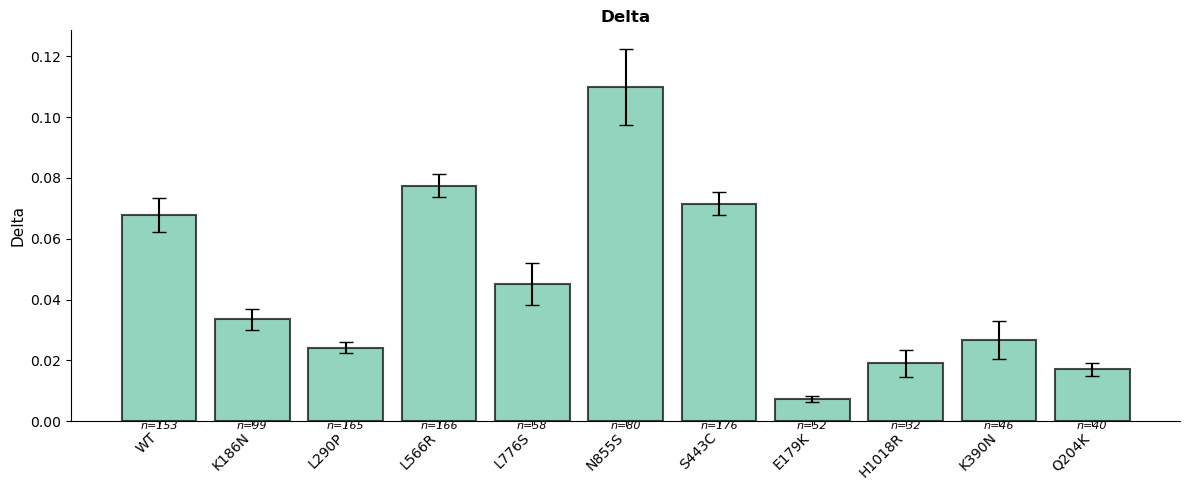

In [8]:
fig2, axes = plt.subplots(figsize=(12, 5))

#for idx, metric in enumerate(['amplitude', 'auc']):
#    ax = axes[idx]

ax = axes
colors = plt.cm.Set2(np.linspace(0, 1, len(data)))

groups = list(data.columns)
means = [np.mean(data[g]) for g in groups]
sems = [stats.sem(data[g],nan_policy='omit') for g in groups]

x_pos = np.arange(len(groups))
bars = ax.bar(x_pos, means, yerr=sems, capsize=5,
             color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Individual points
for i, group in enumerate(groups):
    values = data[group]
    x_jitter = np.random.normal(i, 0.05, size=len(values))
    
    #ax.scatter(x_jitter, values, color='black', alpha=0.5, s=30, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(groups, rotation=45, ha='right')
ax.set_ylabel("delta".title(), fontsize=11)
ax.set_title(f'{"delta".title()}', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add sample sizes
for i, group in enumerate(groups):
    n = data[group].count()
    ax.text(i, ax.get_ylim()[0], f'n={n}', ha='center',
           va='top', fontsize=8, style='italic')

plt.tight_layout()

In [9]:
sems

[0.005482544983259314,
 0.0034612910148566103,
 0.001826590039146778,
 0.0037247362522470147,
 0.007015684814369946,
 0.012502107790401635,
 0.00382938169695462,
 0.0009536729912189636,
 0.004326230029570941,
 0.006207220885321615,
 0.0021137955182257548]

In [10]:
groups = list(data.columns)
datap = [data[g].dropna() for g in groups]

# ANOVA
f_stat, p_val = stats.f_oneway(*datap)

# Effect size
grand_mean = np.mean(np.concatenate(datap))
ss_between = sum(len(d) * (np.mean(d) - grand_mean)**2 for d in datap)
ss_total = sum(np.sum((d - grand_mean)**2) for d in datap)
eta_squared = ss_between / ss_total

results = {
    'metric': "delta",
    'F_statistic': f_stat,
    'p_value': p_val,
    'eta_squared': eta_squared,
    'significant': p_val < 0.05
}

# Post-hoc: compare each to WT
if p_val < 0.05 and 'WT' in groups:
    wt_idx = groups.index('WT')
    results['posthoc'] = {}

    for i, group in enumerate(groups):
        if i != wt_idx:
            t_stat, p = stats.ttest_ind(datap[wt_idx], datap[i])
            mean_diff = np.mean(datap[wt_idx]) - np.mean(datap[i])
            pooled_std = np.sqrt((np.var(datap[wt_idx]) + np.var(datap[i])) / 2)
            cohens_d = mean_diff / pooled_std

            results['posthoc'][f'WT vs {group}'] = {
                'p_value': p,
                'mean_diff': mean_diff,
                'cohens_d': cohens_d
            }

In [11]:
results

{'metric': 'delta',
 'F_statistic': 30.32085504299121,
 'p_value': 1.1049648136836663e-51,
 'eta_squared': 0.22307728297766255,
 'significant': True,
 'posthoc': {'WT vs K186N': {'p_value': 5.376687685865719e-06,
   'mean_diff': 0.034251896768808555,
   'cohens_d': 0.6391929192821307},
  'WT vs L290P': {'p_value': 1.1144698582294374e-13,
   'mean_diff': 0.043580484112837076,
   'cohens_d': 0.8616685505815698},
  'WT vs L566R': {'p_value': 0.1373086582347915,
   'mean_diff': -0.009740249982188323,
   'cohens_d': -0.1663358536803923},
  'WT vs L776S': {'p_value': 0.02298338057122125,
   'mean_diff': 0.02268046426424976,
   'cohens_d': 0.3735113706726481},
  'WT vs N855S': {'p_value': 0.00041919575624272114,
   'mean_diff': -0.04220548922346719,
   'cohens_d': -0.4589074974979062},
  'WT vs S443C': {'p_value': 0.5601099610625928,
   'mean_diff': -0.0038245051798932173,
   'cohens_d': -0.06403103410614962},
  'WT vs E179K': {'p_value': 1.005690238045181e-09,
   'mean_diff': 0.0604718693427

In [12]:
for item in results["posthoc"].keys():
    outcome = results["posthoc"][item]
    if outcome["p_value"]<(0.05/((len(results["posthoc"].keys())**0.5))):
        print(item)
        print(outcome)

WT vs K186N
{'p_value': 5.376687685865719e-06, 'mean_diff': 0.034251896768808555, 'cohens_d': 0.6391929192821307}
WT vs L290P
{'p_value': 1.1144698582294374e-13, 'mean_diff': 0.043580484112837076, 'cohens_d': 0.8616685505815698}
WT vs N855S
{'p_value': 0.00041919575624272114, 'mean_diff': -0.04220548922346719, 'cohens_d': -0.4589074974979062}
WT vs E179K
{'p_value': 1.005690238045181e-09, 'mean_diff': 0.06047186934274041, 'cohens_d': 1.258841298384167}
WT vs H1018R
{'p_value': 8.794838320944134e-05, 'mean_diff': 0.04882608348895118, 'cohens_d': 0.9622826761754272}
WT vs K390N
{'p_value': 0.00014117184353211785, 'mean_diff': 0.04104511766059081, 'cohens_d': 0.7311616795978653}
WT vs Q204K
{'p_value': 5.114455763311718e-06, 'mean_diff': 0.05067349974712107, 'cohens_d': 1.040552275122835}


In [13]:
0.05/len(results["posthoc"].keys())**0.5

0.015811388300841896

  # Testing for loss of response


EQUIVALENCE TEST RESULTS: Testing if Δ(CA - Basal) ≈ 0
Equivalence bound: ±0.100

WT (n=10)
  Mean delta: 0.7224 ± 0.0114
  90% CI: [0.7014, 0.7434]
  Cohen's d: 19.983

  Tests:
    Equivalence (TOST): p = 1.0000 ✗ NOT EQUIVALENT
    Difference (t-test): p = 0.0000 ✓ DIFFERENT

  ➜ CLEAR RESPONSE (different from zero)
--------------------------------------------------------------------------------

E179K (n=8)
  Mean delta: -0.0009 ± 0.0087
  90% CI: [-0.0174, 0.0155]
  Cohen's d: -0.039

  Tests:
    Equivalence (TOST): p = 0.0000 ✓ EQUIVALENT
    Difference (t-test): p = 5.4952 ✗ NOT DIFFERENT

  ➜ NO RESPONSE (equivalent to zero)
--------------------------------------------------------------------------------

H1018R (n=9)
  Mean delta: 0.3142 ± 0.0247
  90% CI: [0.2682, 0.3603]
  Cohen's d: 4.233

  Tests:
    Equivalence (TOST): p = 1.0000 ✗ NOT EQUIVALENT
    Difference (t-test): p = 0.0000 ✓ DIFFERENT

  ➜ CLEAR RESPONSE (different from zero)
----------------------------------

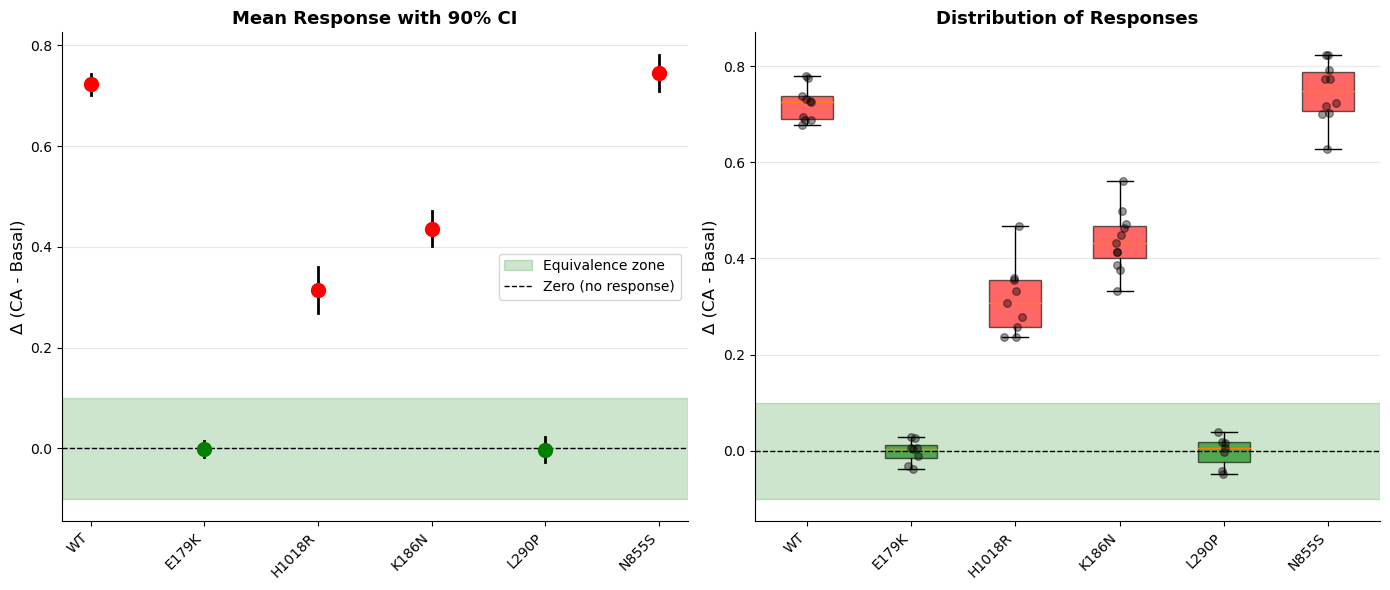

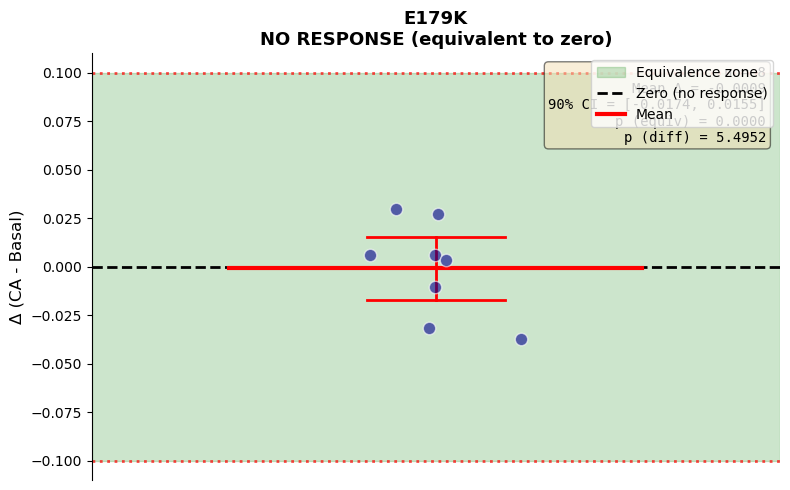


✓ Results saved to 'equivalence_test_results.csv'


In [14]:
class EquivalenceAnalyzer:
    """
    Perform equivalence testing on delta values (CA - Basal)
    Tests if deltas are equivalent to zero (no response)
    """
    
    def __init__(self, df_deltas, equivalence_bound=0.1):
        """
        Parameters:
        -----------
        df_deltas : DataFrame
            Each column is a genotype, each row is a replicate
            Values are CA_response - Basal
        equivalence_bound : float
            Maximum delta considered "equivalent to zero"
            Represents "no functional response"
        """
        self.df = df_deltas
        self.equivalence_bound = equivalence_bound
        self.results = {}
        
    def test_genotype(self, genotype, total_tests=1):
        """
        Test if one genotype shows no response (delta ≈ 0)
        """
        deltas = self.df[genotype].dropna().values
        n = len(deltas)
        
        if n < 3:
            return {
                'genotype': genotype,
                'n': n,
                'error': 'Insufficient data (n < 3)'
            }
        
        # Descriptive statistics
        mean_delta = np.mean(deltas)
        std_delta = np.std(deltas, ddof=1)
        sem_delta = stats.sem(deltas)
        
        # One-sample t-test vs zero (for reference)
        t_stat, p_diff = stats.ttest_1samp(deltas, 0)
        # correct pdiff for bonferroni multiple tests
        p_diff *= total_tests
        
        # TOST: Two One-Sided Tests for equivalence to zero
        # Test 1: delta > -equivalence_bound
        t1 = (mean_delta + self.equivalence_bound) / sem_delta
        p1 = total_tests * stats.t.sf(t1, n - 1)
        
        # Test 2: delta < +equivalence_bound
        t2 = (mean_delta - self.equivalence_bound) / sem_delta
        p2 = total_tests * stats.t.cdf(t2, n - 1)
        """        print("=DEBUG=")
        print(genotype)
        print(self.equivalence_bound)
        print(mean_delta)
        print(sem_delta)
        print(t1)
        print(t2)
        print(p1)
        print(p2)
        print("=DEBUG END=")"""
        # Equivalence test p-value (max of the two), clipped for bonferroni
        p_equivalence = min(1,max(p1, p2))
        
        # 90% Confidence interval (for equivalence at α=0.05)
        t_crit = stats.t.ppf(0.95, n - 1)  # 90% CI
        ci_lower = mean_delta - t_crit * sem_delta
        ci_upper = mean_delta + t_crit * sem_delta
        
        # Check if CI is entirely within equivalence bounds
        ci_within_bounds = (ci_lower > -self.equivalence_bound and 
                           ci_upper < self.equivalence_bound)
        
        # Effect size (standardized mean difference from zero)
        cohens_d = mean_delta / std_delta if std_delta > 0 else 0
        
        # Classification
        is_equivalent = p_equivalence < 0.05
        is_different = p_diff < 0.05
        
        if is_equivalent and not is_different:
            interpretation = "NO RESPONSE (equivalent to zero)"
            status = "non_responder"
        elif is_different and not is_equivalent:
            interpretation = "CLEAR RESPONSE (different from zero)"
            status = "responder"
        elif is_equivalent and is_different:
            interpretation = "TRIVIAL RESPONSE (statistically significant but biologically negligible)"
            status = "weak_responder"
        else:
            interpretation = "INCONCLUSIVE (need more data)"
            status = "inconclusive"
        
        return {
            'genotype': genotype,
            'n': n,
            'mean_delta': mean_delta,
            'sem_delta': sem_delta,
            'std_delta': std_delta,
            'ci_90': (ci_lower, ci_upper),
            'equivalence_bound': self.equivalence_bound,
            'p_equivalence': p_equivalence,
            'is_equivalent': is_equivalent,
            'p_difference': p_diff,
            'is_different': is_different,
            'cohens_d': cohens_d,
            'ci_within_bounds': ci_within_bounds,
            'interpretation': interpretation,
            'status': status
        }
    
    def test_all(self):
        """Test all genotypes in the DataFrame"""
        for genotype in self.df.columns:
            result = self.test_genotype(genotype, len(self.df.columns)) # 
            self.results[genotype] = result
        
        return self.results
    
    def summary_table(self):
        """Create summary table of results"""
        if not self.results:
            self.test_all()
        
        summary_data = []
        for genotype, result in self.results.items():
            if 'error' in result:
                continue
                
            summary_data.append({
                'Genotype': genotype,
                'n': result['n'],
                'Mean Δ': result['mean_delta'],
                'SEM': result['sem_delta'],
                '90% CI Lower': result['ci_90'][0],
                '90% CI Upper': result['ci_90'][1],
                'p (equiv)': result['p_equivalence'],
                'p (diff)': result['p_difference'],
                "Cohen's d": result['cohens_d'],
                'Status': result['status'],
                'Interpretation': result['interpretation']
            })
        
        return pd.DataFrame(summary_data)
    
    def print_results(self):
        """Print formatted results"""
        if not self.results:
            self.test_all()
        
        print("\n" + "="*80)
        print("EQUIVALENCE TEST RESULTS: Testing if Δ(CA - Basal) ≈ 0")
        print("="*80)
        print(f"Equivalence bound: ±{self.equivalence_bound:.3f}")
        print("="*80 + "\n")
        
        for genotype, result in self.results.items():
            if 'error' in result:
                print(f"{genotype}: {result['error']}\n")
                continue
            
            print(f"{genotype} (n={result['n']})")
            print(f"  Mean delta: {result['mean_delta']:.4f} ± {result['sem_delta']:.4f}")
            print(f"  90% CI: [{result['ci_90'][0]:.4f}, {result['ci_90'][1]:.4f}]")
            print(f"  Cohen's d: {result['cohens_d']:.3f}")
            print(f"\n  Tests:")
            print(f"    Equivalence (TOST): p = {result['p_equivalence']:.4f} "
                  f"{'✓ EQUIVALENT' if result['is_equivalent'] else '✗ NOT EQUIVALENT'}")
            print(f"    Difference (t-test): p = {result['p_difference']:.4f} "
                  f"{'✓ DIFFERENT' if result['is_different'] else '✗ NOT DIFFERENT'}")
            print(f"\n  ➜ {result['interpretation']}")
            print("-" * 80 + "\n")
    
    def plot_results(self, figsize=(14, 6)):
        """Visualize equivalence test results"""
        if not self.results:
            self.test_all()
        
        # Filter out errors
        valid_results = {k: v for k, v in self.results.items() if 'error' not in v}
        genotypes = list(valid_results.keys())
        n_genotypes = len(genotypes)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # Plot 1: Means with CI and equivalence bounds
        colors = []
        for i, genotype in enumerate(genotypes):
            result = valid_results[genotype]
            mean = result['mean_delta']
            ci_lower, ci_upper = result['ci_90']
            
            # Color by status
            if result['status'] == 'non_responder':
                color = 'green'
            elif result['status'] == 'responder':
                color = 'red'
            elif result['status'] == 'weak_responder':
                color = 'orange'
            else:
                color = 'gray'
            
            colors.append(color)
            
            # Plot CI
            ax1.plot([i, i], [ci_lower, ci_upper], 'k-', linewidth=2)
            ax1.plot(i, mean, 'o', color=color, markersize=10, zorder=3)
        
        # Equivalence bounds
        ax1.axhspan(-self.equivalence_bound, self.equivalence_bound, 
                   alpha=0.2, color='green', label='Equivalence zone')
        ax1.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero (no response)')
        
        ax1.set_xticks(range(n_genotypes))
        ax1.set_xticklabels(genotypes, rotation=45, ha='right')
        ax1.set_ylabel('Δ (CA - Basal)', fontsize=12)
        ax1.set_title('Mean Response with 90% CI', fontsize=13, fontweight='bold')
        ax1.legend(loc='best')
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(axis='y', alpha=0.3)
        
        # Plot 2: Box plots of deltas
        box_data = [self.df[g].dropna() for g in genotypes]
        bp = ax2.boxplot(box_data, labels=genotypes, patch_artist=True,
                        showfliers=True)
        
        # Color boxes
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        
        # Add individual points
        for i, genotype in enumerate(genotypes):
            values = self.df[genotype].dropna()
            x_jitter = np.random.normal(i + 1, 0.04, size=len(values))
            ax2.scatter(x_jitter, values, color='black', alpha=0.4, s=30, zorder=3)
        
        # Equivalence bounds
        ax2.axhspan(-self.equivalence_bound, self.equivalence_bound,
                   alpha=0.2, color='green')
        ax2.axhline(0, color='black', linestyle='--', linewidth=1)
        
        ax2.set_xticklabels(genotypes, rotation=45, ha='right')
        ax2.set_ylabel('Δ (CA - Basal)', fontsize=12)
        ax2.set_title('Distribution of Responses', fontsize=13, fontweight='bold')
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        return fig
    
    def plot_individual_genotype(self, genotype, figsize=(8, 5)):
        """Detailed plot for one genotype"""
        if genotype not in self.results:
            self.test_genotype(genotype)
        
        result = self.results[genotype]
        
        if 'error' in result:
            print(f"Cannot plot {genotype}: {result['error']}")
            return
        
        fig, ax = plt.subplots(figsize=figsize)
        
        deltas = self.df[genotype].dropna()
        mean = result['mean_delta']
        ci_lower, ci_upper = result['ci_90']
        
        # Equivalence zone
        ax.axhspan(-self.equivalence_bound, self.equivalence_bound,
                  alpha=0.2, color='green', label='Equivalence zone')
        ax.axhline(0, color='black', linestyle='--', linewidth=2, 
                  label='Zero (no response)')
        
        # Data points
        x_jitter = np.random.normal(0, 0.05, size=len(deltas))
        ax.scatter(x_jitter, deltas, color='darkblue', alpha=0.6, 
                  s=80, zorder=3, edgecolors='white', linewidth=1)
        
        # Mean and CI
        ax.plot([-0.3, 0.3], [mean, mean], 'r-', linewidth=3, label='Mean')
        ax.plot([0, 0], [ci_lower, ci_upper], 'r-', linewidth=2)
        ax.plot([-0.1, 0.1], [ci_lower, ci_lower], 'r-', linewidth=2)
        ax.plot([-0.1, 0.1], [ci_upper, ci_upper], 'r-', linewidth=2)
        
        # Equivalence bounds
        ax.axhline(self.equivalence_bound, color='red', linestyle=':', 
                  alpha=0.7, linewidth=2)
        ax.axhline(-self.equivalence_bound, color='red', linestyle=':', 
                  alpha=0.7, linewidth=2)
        
        ax.set_xlim(-0.5, 0.5)
        ax.set_xticks([])
        ax.set_ylabel('Δ (CA - Basal)', fontsize=12)
        ax.set_title(f'{genotype}\n{result["interpretation"]}',
                    fontsize=13, fontweight='bold')
        ax.legend(loc='best')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        
        # Add statistics text
        stats_text = f"n = {result['n']}\n"
        stats_text += f"Mean Δ = {mean:.4f}\n"
        stats_text += f"90% CI = [{ci_lower:.4f}, {ci_upper:.4f}]\n"
        stats_text += f"p (equiv) = {result['p_equivalence']:.4f}\n"
        stats_text += f"p (diff) = {result['p_difference']:.4f}"
        
        ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
               fontsize=10, family='monospace')
        
        plt.tight_layout()
        return fig


# ============================================================================
# USAGE EXAMPLE
# ============================================================================

# Example: Create delta DataFrame (your actual deltas)
np.random.seed(42)

syn_data = {
    'WT': np.random.normal(0.70, 0.05, 10),        # 10 values
    'E179K': np.random.normal(0.02, 0.03, 8),      # 8 values
    'H1018R': np.random.normal(0.35, 0.08, 9),     # 9 values
    'K186N': np.random.normal(0.45, 0.06, 11),     # 11 values
    'L290P': np.random.normal(0.01, 0.04, 7),      # 7 values
    'N855S': np.random.normal(0.75, 0.07, 10),     # 10 values
}

# Find maximum length
max_len = max(len(v) for v in syn_data.values())

# Pad each array with NaN to match max length
df_deltas = pd.DataFrame({
    key: np.pad(value, (0, max_len - len(value)), 
                constant_values=np.nan)
    for key, value in syn_data.items()
})

# Initialize analyzer
analyzer = EquivalenceAnalyzer(df_deltas, equivalence_bound=0.1)

# Run all tests
analyzer.test_all()

# Print results
analyzer.print_results()

# Get summary table
summary = analyzer.summary_table()
print("\nSUMMARY TABLE:")
print(summary.to_string(index=False))

# Plot all results
fig = analyzer.plot_results()
plt.savefig('equivalence_all_genotypes.png', dpi=300, bbox_inches='tight')

# Plot individual genotype
fig_e179k = analyzer.plot_individual_genotype('E179K')
plt.savefig('equivalence_E179K.png', dpi=300, bbox_inches='tight')

plt.show()

# Export results to CSV
summary.to_csv('equivalence_test_results.csv', index=False)
print("\n✓ Results saved to 'equivalence_test_results.csv'")




EQUIVALENCE TEST RESULTS: Testing if Δ(CA - Basal) ≈ 0
Equivalence bound: ±0.014

WT (n=153)
  Mean delta: 0.0678 ± 0.0055
  90% CI: [0.0587, 0.0768]
  Cohen's d: 0.999

  Tests:
    Equivalence (TOST): p = 1.0000 ✗ NOT EQUIVALENT
    Difference (t-test): p = 0.0000 ✓ DIFFERENT

  ➜ CLEAR RESPONSE (different from zero)
--------------------------------------------------------------------------------

K186N (n=99)
  Mean delta: 0.0335 ± 0.0035
  90% CI: [0.0278, 0.0393]
  Cohen's d: 0.973

  Tests:
    Equivalence (TOST): p = 1.0000 ✗ NOT EQUIVALENT
    Difference (t-test): p = 0.0000 ✓ DIFFERENT

  ➜ CLEAR RESPONSE (different from zero)
--------------------------------------------------------------------------------

L290P (n=165)
  Mean delta: 0.0242 ± 0.0018
  90% CI: [0.0212, 0.0272]
  Cohen's d: 1.031

  Tests:
    Equivalence (TOST): p = 1.0000 ✗ NOT EQUIVALENT
    Difference (t-test): p = 0.0000 ✓ DIFFERENT

  ➜ CLEAR RESPONSE (different from zero)
-------------------------------

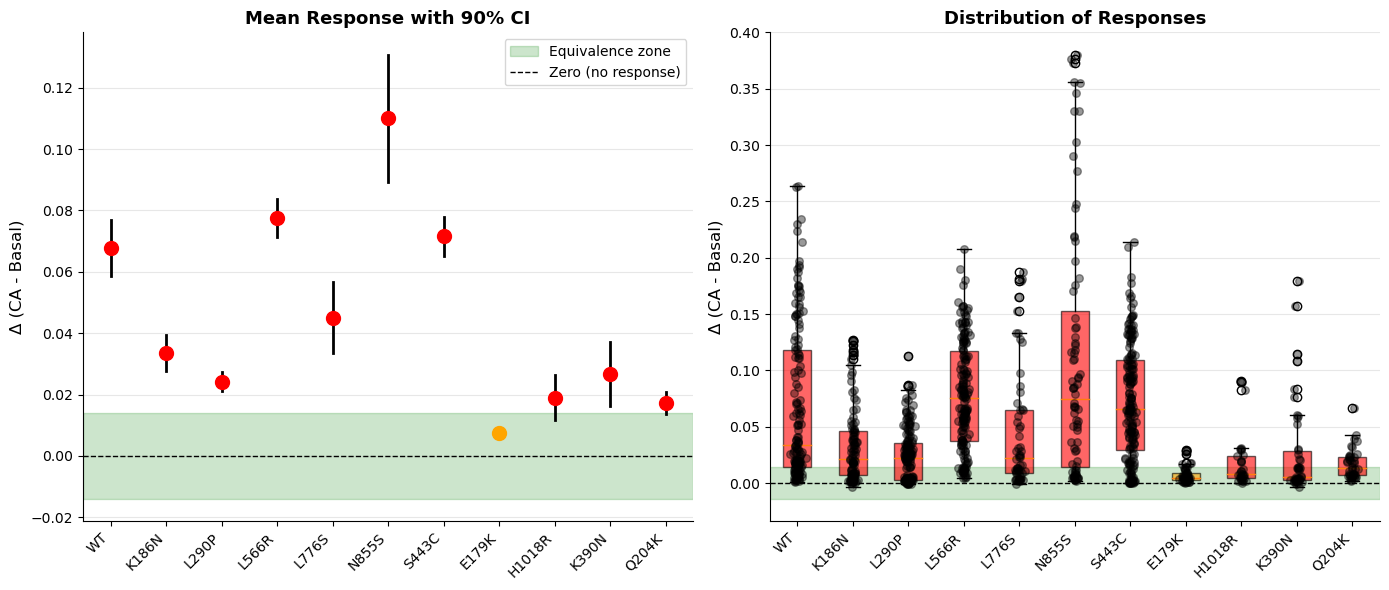

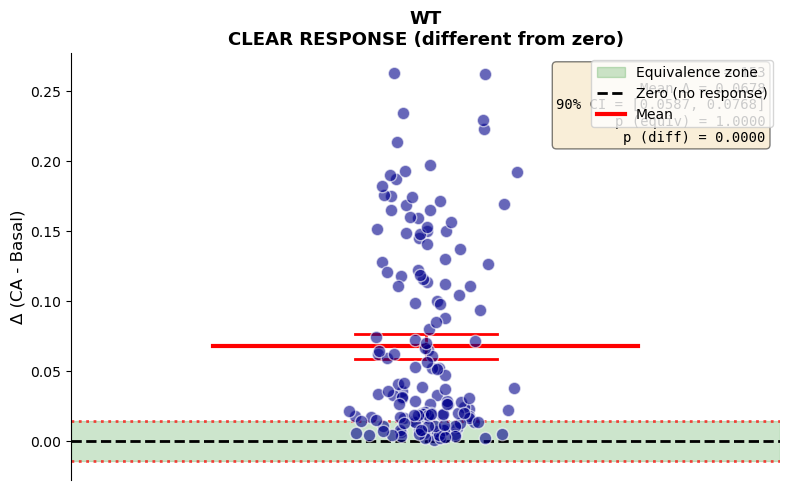

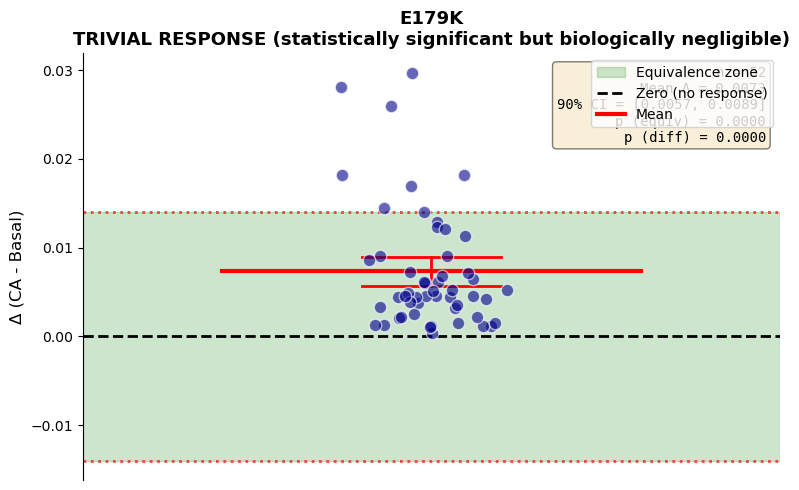

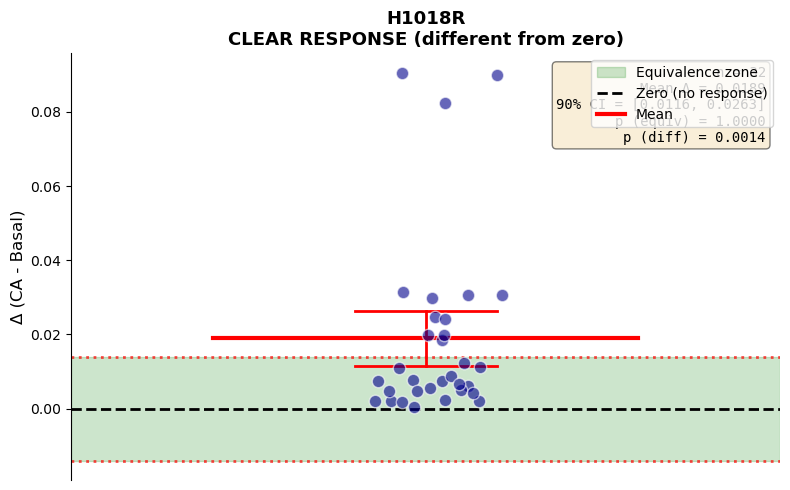


✓ Results saved to 'equivalence_test_results.csv'


In [15]:
# real data

# Initialize analyzer
analyzer = EquivalenceAnalyzer(data, equivalence_bound=0.014) # bound determined from WT mean- 0.2*0.07

# Run all tests
analyzer.test_all()

# Print results
analyzer.print_results()

# Get summary table
summary = analyzer.summary_table()
print("\nSUMMARY TABLE:")
print(summary.to_string(index=False))

# Plot all results
fig = analyzer.plot_results()
plt.savefig('equivalence_all_genotypes.png', dpi=300, bbox_inches='tight')

# Plot individual genotype
fig_wt = analyzer.plot_individual_genotype('WT')
plt.savefig('equivalence_wt.png', dpi=300, bbox_inches='tight')

# Plot individual genotype
fig_e179k = analyzer.plot_individual_genotype('E179K')
plt.savefig('equivalence_E179K.png', dpi=300, bbox_inches='tight')

# Plot individual genotype
fig_e179k = analyzer.plot_individual_genotype('H1018R')
plt.savefig('equivalence_H1018R.png', dpi=300, bbox_inches='tight')

plt.show()

# Export results to CSV
summary.to_csv('equivalence_test_results.csv', index=False)
print("\n✓ Results saved to 'equivalence_test_results.csv'")

